In [1]:
!pip install pennylane          # PennyLane 是一個專門為「量子計算」設計的開源 Python 軟體庫
!pip install scikit-learn       # 用於處理一些傳統機器學習的任務，包含一些基礎的資料讀取分割功能 (後續程式碼將會使用到)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 23.4 MB/s eta 0:00:00


In [2]:
import pennylane as qml                                 # pennylane 量子模型庫
from pennylane import numpy as np                       # pennylane 自帶的 numpy 庫，numpy 大幅改善了 python 數值計算緩慢的問題

import matplotlib.pyplot as plt                         # 在這裡用於畫折線圖、顯示圖片

from sklearn.datasets import fetch_openml               # 用於讀取 MNIST 數據
from sklearn.decomposition import PCA                   # 用於數據降維
from sklearn.model_selection import train_test_split    # 用於資料自動分割
from sklearn.preprocessing import MinMaxScaler          # 用於縮放數據範圍
from skimage.transform import resize                    # 調整圖片長寬大小

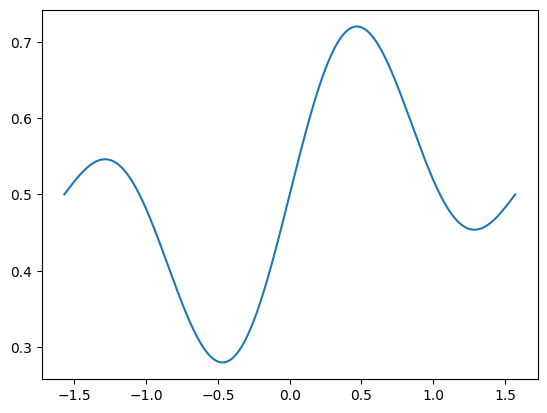

In [23]:

num_of_data = 1000
x = np.linspace(-np.pi/2, np.pi/2, num_of_data)
y = (np.sin(2 * x) + np.sin(4 * x) + 4) / 8

plt.plot(x, y)
plt.show()

In [24]:
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=750, test_size=250, random_state=42)

In [25]:
n_qubits = 8
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def circuit_HEA(num_qubits, num_layers, weights, features):
    for i in range(num_qubits):
        qml.RX(features*(i+1), wires=i)
    qml.Barrier()

    # 變分層 (可重複堆疊增加複雜度)
    c = 0
    for i in range(num_layers):
        # 這裡會再單個 qubit 進行一個完整的 unitary 旋轉 (可以想像成在單個 qubit 的 bloch sphere 中轉到任何方向)
        for j in range(num_qubits):
            qml.U3(weights[c], weights[c+1], weights[c+2], wires=j)
            c += 3

        # 這裡是一個全連結的糾纏層，讓 qubit 與 qubit 之間所取得的特徵進行交互
        for j in range(num_qubits - 1):
            qml.CNOT(wires=[j, j + 1])
        qml.Barrier()


    # 量測最後一個 qubit，這將會回傳有兩個數值的 list，分別是 -> [測量為 |0> 的機率, 測量為 |1> 的機率]
    return qml.probs(wires=0)

(<Figure size 6500x400 with 1 Axes>, <Axes: >)

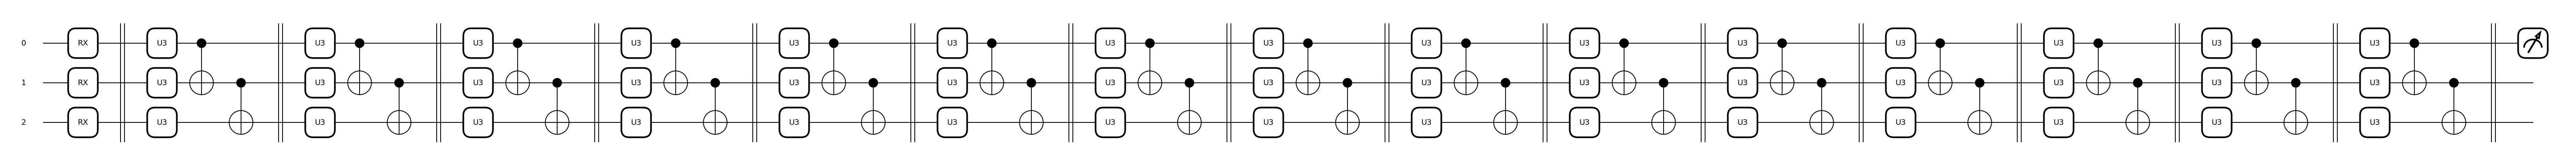

In [26]:
circuit_choose = "HEA"  # HEA or QCNN

# 初始化參數
num_qubits = 3  # qubit 數量
num_layers = 15  # 層數，如果是在 QCNN 的情況下，只能是 3

# 計算 parameter 數量
if circuit_choose == "HEA":
    num_parameters = num_layers * num_qubits * 3                # 每層使用 15 個參數
    circuit = circuit_HEA

# 隨機生成可訓練的參數，數值範圍 [low, high] 在 [-pi, pi] 之間，長度為 size
weights = np.random.uniform(low = -np.pi, high = np.pi, size = num_parameters, requires_grad=True)

# 畫出電路圖
qml.draw_mpl(circuit)(num_qubits, num_layers, weights, x_train[0])

In [27]:
def loss_func(weights, x, y):
    # 將 data 與要訓練的權重丟到量子模型當中，並且只拿 "測量為 |1> 的機率"
    # 因此當 "測量為 |1> 的機率" 為 1，將會於手寫數字 1 做對應
    # 反之當 "測量為 |1> 的機率" 為 0，將會於手寫數字 0 做對應
    predictions = np.array([circuit(num_qubits, num_layers, weights, data)[1] for data in x])

    # 為了與 sin 最大值與最小值做對應，將 predictions 原先是 [0,1] 拉伸至 [-1,1]，而這意思同時也是測量為 |1> 的期望值
    predictions = predictions

    # 使用平方誤差 (MSE) 損失函數 -> 用來檢測量子模型預測的與真實結果的差距，我們會希望這個數值越小越好
    loss = np.mean((predictions - y)**2)

    # 回傳損失函數
    return loss

In [28]:
# 4. 開始訓練
# 設定超參數 (控制模型學習過程的參數)
iterations = 20         # 訓練次數
batch_size = 10         # 每次訓練所使用的 data 數量
learning_rate = 0.05    # 每次更新參數的步長
opt = qml.AdamOptimizer(stepsize=learning_rate)     # 利用梯度下降優化器
loss_list = []                                      # 用於紀錄 loss 數值的變化

start = 0
total_step = 0

# 隨機生成可訓練的參數，數值範圍 [low, high] 在 [-pi, pi] 之間，長度為 size
weights = np.random.uniform(low = -np.pi, high = np.pi, size = num_parameters, requires_grad=True)

In [31]:
print("開始訓練量子模型...")
for i in range(start, iterations):
    # 隨機抽樣 batch_size 個 data
    batch_index = np.random.randint(0, len(x_train), (batch_size,))
    x_batch = x_train[batch_index]
    y_batch = y_train[batch_index]

    # loss_func 中會把每個 data 分別丟到量子電路當中，並計算 loss(損失)
    weights, loss = opt.step_and_cost(lambda w: loss_func(w, x_batch, y_batch), weights)
    loss_list.append(loss)

    if (total_step + 1) % 2 == 0:
        print(f"Step {total_step+1:3d} | Loss: {loss:.4f}")
    total_step += 1

開始訓練量子模型...
Step  22 | Loss: 0.0060
Step  24 | Loss: 0.0025
Step  26 | Loss: 0.0036
Step  28 | Loss: 0.0033
Step  30 | Loss: 0.0027
Step  32 | Loss: 0.0032
Step  34 | Loss: 0.0013
Step  36 | Loss: 0.0005
Step  38 | Loss: 0.0007
Step  40 | Loss: 0.0017


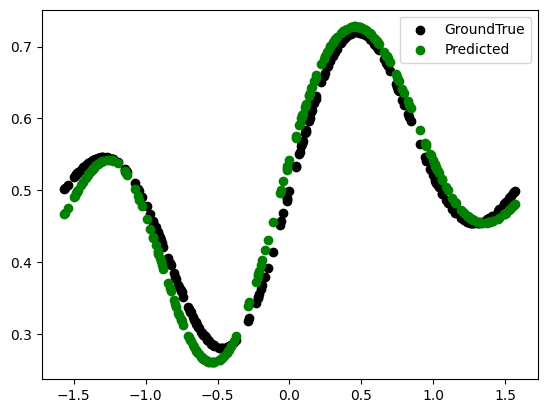

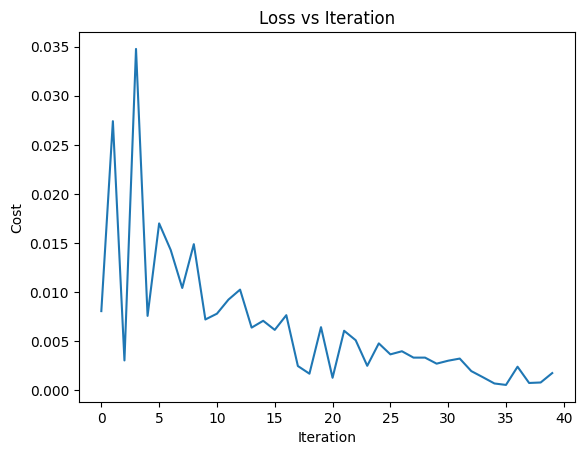

In [32]:
# 5. 測試準確度
def predict(weights, x):
    # 將 data 與訓練完成的權重丟到量子模型當中，並且只拿 "測量為 |1> 的機率"
    predictions = np.array([circuit(num_qubits, num_layers, weights, data)[1] for data in x_test])
    plt.scatter(x_test, y_test, c="black",label = "GroundTrue")
    plt.scatter(x_test, predictions, c="g",label = "Predicted")
    plt.legend()
    plt.show()


predict(weights, x)


# loss 變化折線圖 (Loss 有下降代表有在訓練)
plt.plot(loss_list)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Loss vs Iteration")
plt.show()